# Universal Top-Hat (Fixed $\theta_c=5^\circ$) + $E_{iso}$ Recovery

This notebook reruns a universal top-hat model with a fixed core angle and free jet fraction $f_j$.

Model parameters sampled by MCMC:
- `A_index`
- `L_L0`
- `L_mu_E`
- `sigma_E`
- `f_j`

Then it extracts the expected isotropic-equivalent energy from the luminosity distribution using:
$$E_{iso} \simeq \xi \; L_{peak} \; T$$
with default `xi=0.3` and `T=1.0 s` (Salafia et al. 2023 style conversion).

In [121]:
%load_ext autoreload
%autoreload 2

import notebook_setup
import src.init
import emcee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import inf
from pathlib import Path

from src.top_hat.montecarlo import (
    create_k_interpolator,
    create_log_probability_function,
    simplified_montecarlo,
    apply_detection_cuts,
    score_func_cvm,
    poiss_log,
    run_mcmc,
    check_and_resume_mcmc,
    compute_luminosity_distance,
)

plt.style.use('../configurations/style.mplstyle')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [124]:
# Global setup
datafiles           = Path('../datafiles')
N_WALKERS           = 20
N_STEPS             = 20_000
N_PARAMS            = 5
PARAM_NAMES         = ['A_index', 'L_L0', 'L_mu_E', 'sigma_E', 'f_j']
THETA_C_DEG_FIXED   = 5
MAX_FJ              = 10.0

In [125]:
# Prior and likelihood with fixed theta_c
def log_prior_fixed_theta(thetas):
    A_index, L_L0, L_mu_E, sigma_E, fj = thetas

    if not (1.5 < A_index < 5):
        return -inf
    if not (-2 < L_L0 < 6):
        return -inf
    if not (1 < L_mu_E < 6.5):
        return -inf
    if not (0 < sigma_E < 1.8):
        return -inf
    if not (0 < fj < MAX_FJ):
        return -inf

    return 0.0


def log_likelihood_fixed_theta(thetas, params_in, distances, k_interpolator, n_events=10_000):
    A_index, L_L0, L_mu_E, sigma_E, fj = thetas

    theta_c_rad = np.radians(THETA_C_DEG_FIXED)
    geometric_factor = 1.0 - np.cos(theta_c_rad)
    epsilon = fj * geometric_factor

    gbm_eff = 0.6
    n_years = params_in.triggered_years
    intrinsic_rate_per_year = epsilon * len(params_in.z_arr) * gbm_eff
    expected_total_events = intrinsic_rate_per_year * n_years

    if expected_total_events < 10:
        return -inf, -inf, -inf, -inf, -inf

    results = simplified_montecarlo(thetas, n_events, params_in, distances, k_interpolator)
    trigger_mask, analysis_mask = apply_detection_cuts(results['p_flux'], results['E_p_obs'])

    if np.sum(analysis_mask) <= 3:
        return -inf, -inf, -inf, -inf, -inf

    detected_events = np.sum(trigger_mask)
    detection_efficiency = detected_events / n_events
    predicted_detections = expected_total_events * detection_efficiency

    observed_detections = params_in.yearly_rate * params_in.triggered_years

    l1 = score_func_cvm(results['p_flux'][analysis_mask], params_in.pflux_data, params_in.rng)
    l2 = score_func_cvm(results['E_p_obs'][analysis_mask], params_in.epeak_data, params_in.rng)
    l3 = poiss_log(k=observed_detections, mu=predicted_detections)
    l4 = detection_efficiency

    return l1 + l2 + l3, l1, l2, l3, l4

def initialize_walkers_fixed_theta(n_walkers):
    np.random.seed(42)
    return np.column_stack([
        np.random.uniform(2, 3, n_walkers),      # A_index
        np.random.uniform(2, 4.0, n_walkers),    # L_L0
        np.random.uniform(2.0, 4.0, n_walkers),  # L_mu_E
        np.random.uniform(0.2, 1.0, n_walkers),  # sigma_E
        np.random.uniform(0.5, 2.0, n_walkers),  # f_j
    ])

In [126]:
# Simulation setup
params = {
    'alpha': -0.67,
    'beta_s': -2.59,
    'n': 2,
    'theta_c': THETA_C_DEG_FIXED,
    'theta_v_max': 10,
    'z_model': 'fiducial_Hrad_A1.0',
}

default_params, _, data_dict = src.init.initialize_simulation(datafiles, params=params)
print(f'Total events in the catalogue: {len(default_params.pflux_data)}')

k_interpolator = create_k_interpolator()
log_prob = create_log_probability_function(
    log_prior_func=log_prior_fixed_theta,
    log_likelihood_func=log_likelihood_fixed_theta,
    params_in=default_params,
    k_interpolator=k_interpolator,
)

Using redshift model: samples_fiducial_Hrad_A1.0_BNSs_0.dat with 359079 BNSs.
Computed total merger rate: 360832.5 yr^-1 (local R_0 = 112.0 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Total events in the catalogue: 268


In [127]:
# MCMC run / resume
output_dir = src.init.create_run_dir('Paper_Results/Universal_TopHat_theta5', use_timestamp=False)
filename = output_dir / 'emcee.h5'

initial_pos, n_steps_to_do, backend = check_and_resume_mcmc(
    filename=filename,
    n_steps=N_STEPS,
    initialize_walkers_func=initialize_walkers_fixed_theta,
    n_walkers=N_WALKERS,
)

if n_steps_to_do > 0:
    sampler = run_mcmc(
        log_probability_func=log_prob,
        initial_walkers=initial_pos,
        n_iterations=n_steps_to_do,
        n_walkers=N_WALKERS,
        n_params=N_PARAMS,
        backend=backend,
    )
else:
    print('Run already complete at target steps.')

Creating new directory : Output_files/Paper_Results/Universal_TopHat_theta5
Starting new run


100%|██████████| 20000/20000 [26:17<00:00, 12.68it/s]


In [137]:
# Load posterior samples
backend         = emcee.backends.HDFBackend(output_dir / 'emcee.h5')
DISCARD         = 10_000
flat_samples    = backend.get_chain(discard=DISCARD, thin=15, flat=True)
print('Posterior sample shape:', flat_samples.shape)

best_theta = flat_samples[np.argmax(backend.get_log_prob(discard=DISCARD, thin=15, flat=True))]
print('Best-fit parameters:')
for name, value in zip(PARAM_NAMES, best_theta):
    print(f'  {name:>10s} = {value:.4f}')

log_vals = backend.get_log_prob(discard=DISCARD, thin=15, flat=True)
#best 99% vals 
log_vals_99_location = np.percentile(log_vals, 99.99)
# average parameters for log_vals above the 99% threshold
best_99_params = flat_samples[log_vals >= log_vals_99_location]
best_99_params_mean = np.mean(best_99_params, axis=0)
print('\nAverage parameters for best 99.5% of samples:')
for name, value in zip(PARAM_NAMES, best_99_params_mean):
    print(f'  {name:>10s} = {value:.4f}')

Posterior sample shape: (13320, 5)
Best-fit parameters:
     A_index = 3.5329
        L_L0 = 3.3474
      L_mu_E = 3.2766
     sigma_E = 0.2935
         f_j = 0.2066

Average parameters for best 99.5% of samples:
     A_index = 2.4056
        L_L0 = 2.6201
      L_mu_E = 3.2988
     sigma_E = 0.3190
         f_j = 0.6610


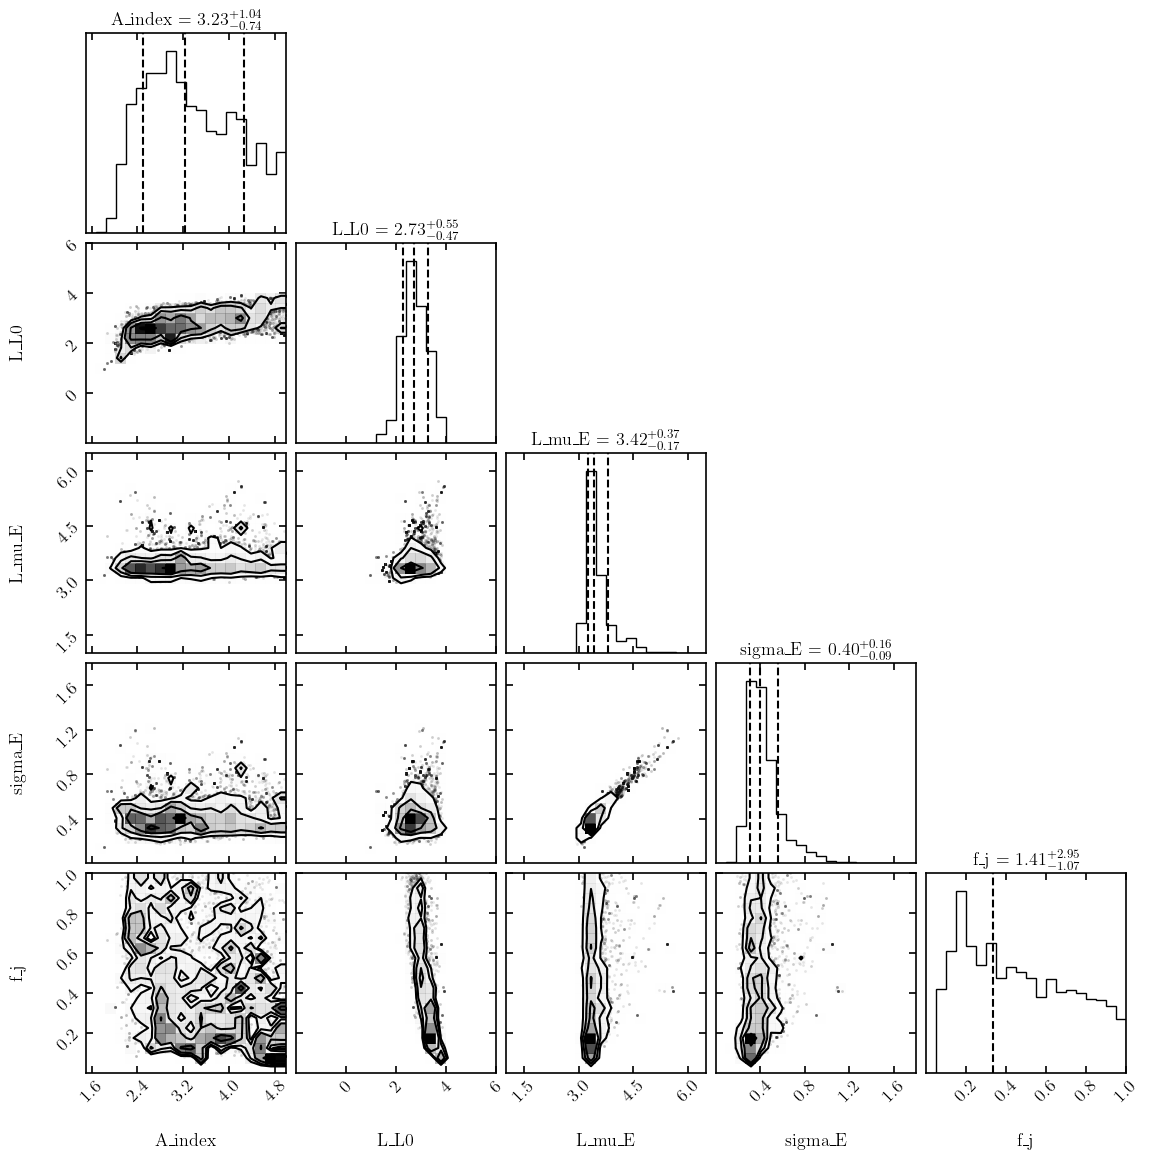

In [138]:
import corner
plot_ranges = [
    [1.5, 5],    # A_index
    [-2, 6],     # L_L0
    [1, 6.5],    # L_mu_E
    [0, 1.8],    # sigma_E
    [0, 1],      # f_j
]

figure = corner.corner(
    flat_samples,
    labels=PARAM_NAMES,
    show_titles=True,
    title_fmt='.2f',
    quantiles=[0.16, 0.5, 0.84],
    range=plot_ranges,
)

## Recover $E_{iso}$ from Peak Luminosity

Implements your requested conversion:
- $\langle L \rangle = \xi L_{peak}$
- $E_{iso} \approx \langle L \rangle T$

In [139]:
def recover_e_iso(peak_luminosity_L, duration_T=1.0, xi=0.3):
    """
    Recover isotropic-equivalent gamma-ray energy from peak luminosity.

    Parameters
    ----------
    peak_luminosity_L : float or np.ndarray
        Isotropic-equivalent peak luminosity in erg/s.
    duration_T : float
        Jet duration in seconds.
    xi : float
        Ratio of average flux to peak flux.

    Returns
    -------
    float or np.ndarray
        Recovered E_iso in erg.
    """
    average_luminosity = xi * peak_luminosity_L
    e_iso = average_luminosity * duration_T
    return e_iso

# Example from your note
L_c = 5e51
recovered_energy = recover_e_iso(L_c)
print(f'Peak Luminosity: {L_c:.2e} erg/s')
print(f'Recovered E_iso: {recovered_energy:.2e} erg')

Peak Luminosity: 5.00e+51 erg/s
Recovered E_iso: 1.50e+51 erg


In [140]:
# Extract E_iso for exactly one-year expectation using BEST-FIT parameters
distances = compute_luminosity_distance(default_params.z_arr)

# Best-fit parameters from chain
log_prob_flat = backend.get_log_prob(discard=DISCARD, thin=15, flat=True)
best_theta = flat_samples[np.argmax(log_prob_flat)]
A_index_best, L_L0_best, L_mu_E_best, sigma_E_best, fj_best = best_theta

# Exactly 1-year expected GRB count: N = len(z_arr) * f_j
n_bns_1yr = len(default_params.z_arr)
n_grb_1yr = int(np.round(n_bns_1yr * fj_best))
n_grb_1yr = max(n_grb_1yr, 1)

rng = np.random.default_rng(123)
sim_best = simplified_montecarlo(
    best_theta,
    n_events=n_grb_1yr,
    params_in=default_params,
    distances=distances,
    k_interpolator=k_interpolator,
    rng=rng,
)

# Associate an isotropic viewing angle to each event: p(theta_v) ~ sin(theta_v)
u = rng.uniform(0.0, 1.0, size=n_grb_1yr)
theta_v_rad = np.arccos(1.0 - u)
theta_v_deg = np.degrees(theta_v_rad)

# Afterglow catalog cut: keep only theta_v <= 15 deg
mask_afterglow = theta_v_deg <= 15.0

L_peak_all = sim_best['L_p_obs'][mask_afterglow]
z_one_year = sim_best['z_arr'][mask_afterglow]
theta_v_deg_kept = theta_v_deg[mask_afterglow]
E_iso_all = recover_e_iso(L_peak_all, duration_T=1.0, xi=0.3)

n_afterglow_15deg = int(np.sum(mask_afterglow))

print('Best-fit parameters used:')
for name, value in zip(PARAM_NAMES, best_theta):
    print(f'  {name:>10s} = {value:.4f}')

print(f'BNS in 1 year (z_arr): {n_bns_1yr:,}')
print(f'Expected GRB emitters in 1 year (round(z_arr * f_j)): {n_grb_1yr:,}')
print(f'Afterglow cut (theta_v <= 15 deg): {n_afterglow_15deg:,}')
print(f'Median log10(L_peak/erg s^-1): {np.median(np.log10(L_peak_all)):.3f}')
print(f'Median log10(E_iso/erg): {np.median(np.log10(E_iso_all)):.3f}')
print('E_iso 16-50-84 percentiles [erg]:')
print(np.percentile(E_iso_all, [16, 50, 84]))

Best-fit parameters used:
     A_index = 3.5329
        L_L0 = 3.3474
      L_mu_E = 3.2766
     sigma_E = 0.2935
         f_j = 0.2066
BNS in 1 year (z_arr): 359,079
Expected GRB emitters in 1 year (round(z_arr * f_j)): 74,183
Afterglow cut (theta_v <= 15 deg): 2,498
Median log10(L_peak/erg s^-1): 52.447
Median log10(E_iso/erg): 51.924
E_iso 16-50-84 percentiles [erg]:
[6.08091739e+51 8.40334808e+51 1.37228556e+52]


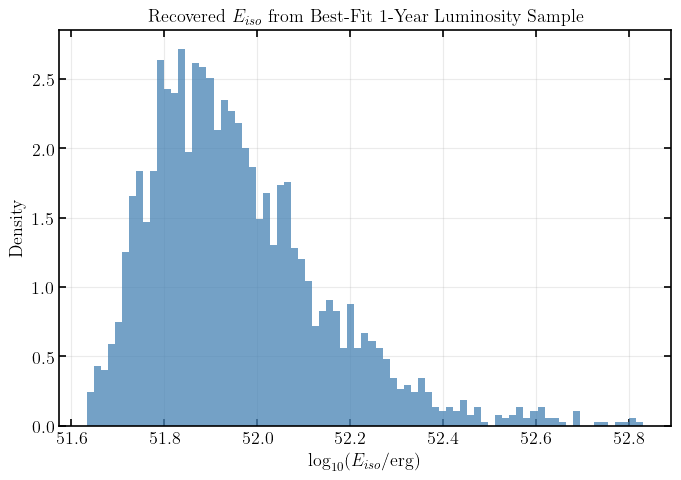

In [141]:
# Plot and save E_iso distribution (best-fit, 1-year extraction)
fig, ax = plt.subplots(figsize=(7, 5))
bins = np.linspace(np.percentile(np.log10(E_iso_all), 0.5), np.percentile(np.log10(E_iso_all), 99.5), 80)
ax.hist(np.log10(E_iso_all), bins=bins, density=True, alpha=0.75, color='steelblue')
ax.set_xlabel(r'$\log_{10}(E_{iso}/\mathrm{erg})$')
ax.set_ylabel('Density')
ax.set_title('Recovered $E_{iso}$ from Best-Fit 1-Year Luminosity Sample')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(output_dir / 'Eiso_recovered_distribution_theta5.pdf', dpi=300)
plt.show()

In [ ]:
#z_arr distribution

In [42]:
# Save summary table and raw E_iso samples
summary = {
    'theta_c_fixed_deg': THETA_C_DEG_FIXED,
    'xi': 0.3,
    'duration_T_s': 1.0,
    'f_j_best': float(fj_best),
    'n_bns_1yr': int(n_bns_1yr),
    'n_grb_1yr': int(n_grb_1yr),
    'n_afterglow_theta15': int(n_afterglow_15deg),
    'log10_Eiso_p16': float(np.percentile(np.log10(E_iso_all), 16)),
    'log10_Eiso_p50': float(np.percentile(np.log10(E_iso_all), 50)),
    'log10_Eiso_p84': float(np.percentile(np.log10(E_iso_all), 84)),
}
summary_df = pd.DataFrame([summary])
summary_df.to_csv(output_dir / 'Eiso_summary_theta5.csv', index=False)

samples_df = pd.DataFrame({
    'z': z_one_year,
    'theta_v_deg': theta_v_deg_kept,
    'L_peak_erg_s': L_peak_all,
    'E_iso_erg': E_iso_all,
})
samples_df.to_csv(output_dir / 'Eiso_samples_theta5.csv', index=False)

print('Saved:')
print(output_dir / 'Eiso_recovered_distribution_theta5.pdf')
print(output_dir / 'Eiso_summary_theta5.csv')
print(output_dir / 'Eiso_samples_theta5.csv')

Saved:
Output_files/Paper_Results/Universal_TopHat_theta5/Eiso_recovered_distribution_theta5.pdf
Output_files/Paper_Results/Universal_TopHat_theta5/Eiso_summary_theta5.csv
Output_files/Paper_Results/Universal_TopHat_theta5/Eiso_samples_theta5.csv
